# Импорты

In [92]:
import pandas
import numpy
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Загрузка

In [93]:
df = pandas.read_csv('spaceship-titanic.csv')
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


# Вспомогательные функции

Рассчитывает соотношение числа групп, где берётся только один член из семьи в группе, где более чем один пассажир, с одинаковыми значениями col в группе

In [94]:
def compute_percent_in_group_without_family(df: pandas.DataFrame, col: str) -> float:
    df_reduced = (
        df
        .sort_values('WithFamily', ascending=False)
        .drop_duplicates(subset=['GroupId', 'Surname', 'WithFamily'])
    )
    df_reduced = df_reduced[
        df_reduced.groupby('GroupId')['GroupId'].transform('count') > 1
    ]

    planet_stats = (
        df_reduced
        .groupby('GroupId')[col]
        .nunique(dropna=True)
    )

    percent = (planet_stats == 1).mean() * 100
    return percent

Заполняет пропуски в column по самому популярному значению при группированию по столбам из group

In [95]:
def fill_nan_with_mode(df: pandas.DataFrame, column: str, group: list[str]) -> int:
    mask = df[column].isna()

    mode_by_dest_cryo = (
        df[~mask]
        .groupby(group)[column]
        .agg(lambda x: x.mode().iloc[0])
    )

    df.loc[mask, column] = (
        df.loc[mask, group]
        .apply(tuple, axis=1)
        .map(mode_by_dest_cryo)
    )

    return df[column].isna().sum()

# Обработка

## Обработка PassengerId

In [96]:
df["GroupId"] = df["PassengerId"].str.split("_").str[0].astype(int)
df = df.drop("PassengerId", axis=1)
df

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,GroupId
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,2
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,3
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,3
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,9276
8689,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,9278
8690,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,9279
8691,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,9280


## Новая фича $-$ WithFamily

In [97]:
df["Surname"] = df["Name"].str.split(" ").str[1]
df = df.drop("Name", axis=1)
df

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,Vines
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther
8689,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley
8690,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon
8691,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre


In [98]:
df["WithFamily"] = (
    df
    .groupby(["GroupId", "Surname"])["Surname"]
    .transform("count")
    .gt(1)
    .astype(int)
)
df.loc[df["Surname"].isna(), "WithFamily"] = numpy.nan
df

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy,0.0
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,Vines,0.0
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent,1.0
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent,1.0
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,Santantines,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther,0.0
8689,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley,0.0
8690,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon,0.0
8691,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre,1.0


## Обработка пропусков и выбросов

In [99]:
df.isna().sum()

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
GroupId           0
Surname         200
WithFamily      200
dtype: int64

### Обработка пропусков и выбросов HomePlanet

In [100]:
df["HomePlanet"].unique()

array(['Europa', 'Earth', 'Mars', nan], dtype=object)

In [101]:
df[df["HomePlanet"].isna()]

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily
59,NaN,True,E/3/S,TRAPPIST-1e,33.0,False,0.0,0.0,NaN,0.0,0.0,True,64,Keen,0.0
113,NaN,False,A/0/P,TRAPPIST-1e,39.0,False,0.0,2344.0,0.0,65.0,6898.0,False,119,Coning,1.0
186,NaN,True,D/6/P,55 Cancri e,24.0,False,0.0,0.0,NaN,0.0,0.0,True,210,Inicont,0.0
225,NaN,False,F/46/S,TRAPPIST-1e,18.0,False,313.0,1.0,691.0,283.0,0.0,False,242,Sté,0.0
234,NaN,True,C/11/S,55 Cancri e,54.0,False,0.0,0.0,0.0,0.0,0.0,True,251,Amsive,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8515,NaN,False,E/582/P,TRAPPIST-1e,25.0,False,1258.0,0.0,22.0,19.0,0.0,False,9084,Mone,0.0
8613,NaN,False,E/603/S,55 Cancri e,53.0,False,0.0,4017.0,0.0,13.0,3147.0,False,9194,NaN,NaN
8666,NaN,False,F/1792/S,55 Cancri e,38.0,NaN,28.0,1208.0,973.0,207.0,0.0,True,9248,Perle,0.0
8674,NaN,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,24.0,0.0,False,9257,Apple,0.0


Рассмотрим отдельно каждые группы, если в этой группе есть семьи, то оставляем лишь одного из членов каждой семьи. Затем рассматриваем те группы, где больше одного пассажира. Уже в этих группах рассчитаем число родных планет, дабы определить отношений групп, где пассажиры с разных планет

In [102]:
compute_percent_in_group_without_family(df, "HomePlanet")

np.float64(99.69135802469135)

Как можно заметить, почти что во всех группах пассажиры с одной планеты, что означает, что в тех группах, где это не так, скорее всего имеется выброс в виде неправильно указанной планеты некоторых пассажиров

In [103]:
mode_planet = (
    df
    .groupby('GroupId')['HomePlanet']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else numpy.nan)
)

df['HomePlanet'] = df['HomePlanet'].fillna(
    df['GroupId'].map(mode_planet)
)
df["HomePlanet"].isna().sum()

np.int64(111)

Проверим, есть ли взаимосвязь HomePlanet с Destination и CryoSleep

In [104]:
pandas.crosstab(df['HomePlanet'], df["Destination"], normalize='index')

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
HomePlanet,,,
Earth,0.152845,0.157918,0.689237
Europa,0.421846,0.008945,0.569209
Mars,0.111175,0.028653,0.860172


In [105]:
pandas.crosstab(df['HomePlanet'], df["CryoSleep"], normalize='index')

CryoSleep,False,True
HomePlanet,,
Earth,0.692478,0.307522
Europa,0.559201,0.440799
Mars,0.608945,0.391055


Можно заметить, что некоторая связь имеется. Из всех пропусков в HomePlanet остались те, которые являются единственными пассажирами в своей группе. Эти пропуски заменим самыми частыми значениями по Destination и CryoSleep.

In [106]:
fill_nan_with_mode(df, "HomePlanet", ["Destination", "CryoSleep"])

np.int64(5)

Оставшиеся заполним просто самым популярным значением HomePlanet

In [107]:
df["HomePlanet"] = df["HomePlanet"].fillna(df["HomePlanet"].mode().iloc[0])
df["HomePlanet"].isna().sum()

np.int64(0)

### Обработка пропусков и выбросов CryoSleep

In [108]:
df["CryoSleep"].isna().sum()

np.int64(217)

Рассмотрим, насколько часто в одной группе из более одного пассажира все пассажиры либо в крио сне, либо нет

In [109]:
compute_percent_in_group_without_family(df, "CryoSleep")

np.float64(56.481481481481474)

Проверим, есть ли взаимосвязь CryoSleep с Destination и Transported

In [110]:
pandas.crosstab(df['CryoSleep'], df['Transported'], normalize='index')

Transported,False,True
CryoSleep,,
False,0.671079,0.328921
True,0.182417,0.817583


In [111]:
pandas.crosstab(df['CryoSleep'], df["Destination"], normalize='index')

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
CryoSleep,,,
False,0.191561,0.074214,0.734225
True,0.247240,0.128137,0.624624


Можно заметить, что некоторая связь имеется. Пропуски заменим самыми частыми значениями по Destination и Transported.

In [112]:
fill_nan_with_mode(df, "CryoSleep", ["Destination", "Transported"])

np.int64(4)

Оставшиеся заполним просто самым популярным значением CryoSleep

In [113]:
df["CryoSleep"] = df["CryoSleep"].fillna(df["CryoSleep"].mode().iloc[0])
df["CryoSleep"].isna().sum()

/tmp/ipykernel_31577/2015310595.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["CryoSleep"] = df["CryoSleep"].fillna(df["CryoSleep"].mode().iloc[0])


np.int64(0)

### Обработка пропусков и выбросов Cabin

In [114]:
df["Cabin"].isna().sum()

np.int64(199)

Так как у каждой группы свой Cabin, то заполняем пропуски тех, кто в одной группе

In [115]:
mode_cabin = (
    df
    .groupby('GroupId')['Cabin']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else numpy.nan)
)

df['Cabin'] = df['Cabin'].fillna(
    df['GroupId'].map(mode_cabin)
)
df["Cabin"].isna().sum()

np.int64(99)

Сначала для большего удобства разделим Cabin на CabinDeck, CabinNumber, CabinSide

In [116]:
df["CabinDeck"] = df["Cabin"].str.split("/").str[0]
df["CabinNumber"] = df["Cabin"].str.split("/").str[1].astype("Int64")
df["CabinSide"] = df["Cabin"].str.split("/").str[2]
df = df.drop("Cabin", axis=1)
df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily,CabinDeck,CabinNumber,CabinSide
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy,0.0,B,0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,Vines,0.0,F,0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent,1.0,A,0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent,1.0,A,0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,Santantines,0.0,F,1,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther,0.0,A,98,P
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley,0.0,G,1499,S
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon,0.0,G,1500,S
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre,1.0,E,608,S


In [117]:
df["CabinDeck"].unique()

array(['B', 'F', 'A', 'G', nan, 'E', 'D', 'C', 'T'], dtype=object)

In [118]:
df["CabinNumber"].unique()

<IntegerArray>
[   0,    1,    2,    3, <NA>,    4,    5,    6,    8,    9,
 ...
 1782, 1884,  353, 1886, 1498, 1888, 1891, 1892, 1893, 1894]
Length: 1818, dtype: Int64

In [119]:
df["CabinSide"].unique()

array(['P', 'S', nan], dtype=object)

Создаём словарь со всеми имеющимися значениями Cabin

In [120]:
cabin: dict[str, dict[str, set[int]]] = defaultdict(lambda: defaultdict(set))

for deck, side, number in (
    df[['CabinDeck', 'CabinSide', 'CabinNumber']]
    .dropna()
    .itertuples(index=False)
):
    cabin[deck][side].add(int(number))

cabin

defaultdict(<function __main__.<lambda>()>,
            {'B': defaultdict(set,
                         {'P': {0,
                           1,
                           3,
                           5,
                           8,
                           9,
                           11,
                           12,
                           15,
                           16,
                           17,
                           18,
                           19,
                           20,
                           21,
                           22,
                           23,
                           24,
                           25,
                           28,
                           32,
                           34,
                           35,
                           36,
                           38,
                           39,
                           40,
                           42,
                           43,
                       

Исходя из этого создадим аналогичный словарь, но с номерами, которые не вошли

In [121]:
missing_cabin: dict[str, dict[str, set[int]]] = defaultdict(lambda: defaultdict(set))
number_counts = 0

for deck, sides in cabin.items():
    missing_cabin[deck] = {}
    for side, numbers in sides.items():
        max_number = max(numbers)
        full_range = set(range(max_number + 1))
        missing_cabin[deck][side] = full_range - numbers
        number_counts += len(missing_cabin[deck][side])

print(number_counts)
missing_cabin

3442


defaultdict(<function __main__.<lambda>()>,
            {'B': {'P': {2,
               4,
               6,
               7,
               10,
               13,
               14,
               26,
               27,
               29,
               30,
               31,
               33,
               37,
               41,
               46,
               48,
               49,
               51,
               52,
               56,
               61,
               62,
               69,
               70,
               71,
               76,
               79,
               82,
               84,
               90,
               91,
               95,
               98,
               99,
               100,
               103,
               108,
               112,
               123,
               131,
               137,
               140,
               147,
               155,
               157,
               163,
               168,
               169,
     

Как можем заметить число пропусков значительно меньше числа недостающих номеров, что значит, что при заполнении придётся искать некоторую зависимость. Можно заметить, что значения CabinNumber для каждого CabinDeck с CabinSide идут в отсортированном порядке

In [122]:
false_count = 0
for deck in df["CabinDeck"].notna().unique():
    for side in df["CabinSide"].unique():
        comparison = (
            df
            .loc[
                (df["CabinSide"] == "P") & (df["CabinDeck"] == deck),
                ["GroupId", "CabinDeck", "CabinNumber", "CabinSide"]
            ]
            .sort_index()
            ==
            df
            .loc[
                (df["CabinSide"] == "P") & (df["CabinDeck"] == deck),
                ["GroupId", "CabinDeck", "CabinNumber", "CabinSide"]
            ]
            .sort_index()
            .sort_values("CabinNumber")
        )

        false_count += (~comparison).sum().sum()

print(false_count)

0


Это означает, что при замечании припуска можно проверить предыдущий и следующий значения набора CabinDeck-CabinNumber-CabinSide для каждого CabinDeck с CabinSide, смотреть какие стоят номера, и если между номерами разница больше одного, то можно заполнить. Когда возможных значений CabinDeck-CabinNumber-CabinSide будет больше 1, то совершается выбор в сторону наиболее часто повторяемого сочетания CabinDeck и CabinSide

In [123]:
def fill_cabin(df: pandas.DataFrame) -> None:
    def fill_nan(df: pandas.DataFrame, idx: int, cabin: dict) -> None:
        df.at[idx, "CabinDeck"] = cabin["deck"]
        df.at[idx, "CabinNumber"] = cabin["number"]
        df.at[idx, "CabinSide"] = cabin["side"]

    for idx in df.index:
        if pandas.isna(df.at[idx, "CabinNumber"]):
            nums = []

            for deck in df[df["CabinDeck"].notna()]["CabinDeck"].unique():
                for side in df[df["CabinDeck"].notna()]["CabinSide"].unique():
                    prev_idx = (
                        df
                        .loc[
                            (df["CabinDeck"] == deck) & (df["CabinSide"] == side),
                            "CabinNumber"
                        ]
                        .sort_index()
                        .loc[:idx]
                        .last_valid_index()
                    )
                    next_idx = (
                        df
                        .loc[
                            (df["CabinDeck"] == deck) & (df["CabinSide"] == side),
                            "CabinNumber"
                        ]
                        .sort_index()
                        .loc[idx:]
                        .first_valid_index()
                    )

                    if next_idx is not None:
                        if prev_idx is None:
                            prev_idx = -1
                            prev_num = -1
                        else:
                            prev_num = df.at[prev_idx, "CabinNumber"]

                        next_num = df.at[next_idx, "CabinNumber"]

                        if next_num - prev_num > 1:
                            nums.append({
                                "deck": deck,
                                "number": prev_num + 1,
                                "side": side,
                                "distance": next_idx - prev_idx,
                                "difference": next_num - prev_num
                            })

            if len(nums) > 0:
                nums.sort(key=lambda x: [x["distance"], x["difference"]])
                fill_nan(df, idx, nums[0])

fill_cabin(df)
df[["CabinDeck", "CabinNumber", "CabinSide"]].isna().sum()

CabinDeck      0
CabinNumber    0
CabinSide      0
dtype: int64

### Обработка пропусков и выбросов Destination

In [124]:
df["Destination"].unique()

array(['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', nan], dtype=object)

In [125]:
df["Destination"].isna().sum()

np.int64(182)

Рассмотрим отдельно каждые группы, если в этой группе есть семьи, то оставляем лишь одного из членов каждой семьи. Затем рассматриваем те группы, где больше одного пассажира. Уже в этих группах рассчитаем число отправных планет, дабы определить отношений групп, где пассажиры летят на одинаковые планет

In [126]:
compute_percent_in_group_without_family(df, "Destination")

np.float64(54.629629629629626)

Проверим, есть ли взаимосвязь Destination с HomePlanet и CabinDeck

In [127]:
pandas.crosstab(df['Destination'], df['HomePlanet'], normalize='index')

HomePlanet,Earth,Europa,Mars
Destination,,,
55 Cancri e,0.389444,0.502778,0.107778
PSO J318.5-22,0.913317,0.023869,0.062814
TRAPPIST-1e,0.541843,0.204396,0.253762


In [128]:
pandas.crosstab(df['Destination'], df['CabinDeck'], normalize='index')

CabinDeck,A,B,C,D,E,F,G,T
Destination,,,,,,,,
55 Cancri e,0.062778,0.191111,0.178889,0.064444,0.065000,0.226111,0.211667,0.000000
PSO J318.5-22,0.002513,0.003769,0.017588,0.022613,0.054020,0.309045,0.590452,0.000000
TRAPPIST-1e,0.024176,0.073542,0.070330,0.058326,0.119358,0.360609,0.292815,0.000845


Можно заметить, что некоторая связь имеется. Пропуски заменим самыми частыми значениями по HomePlanet и CabinDeck.

In [129]:
fill_nan_with_mode(df, "Destination", ["CryoSleep", "Transported"])

np.int64(0)

### Обработка пропусков и выбросов Age

In [130]:
df["Age"].describe([0.05, 0.25, 0.5, 0.75])

count    8514.000000
mean       28.827930
std        14.489021
min         0.000000
5%          4.000000
25%        19.000000
50%        27.000000
75%        38.000000
max        79.000000
Name: Age, dtype: float64

Проверим, есть ли взаимосвязь Age с CryoSleep и WithFamily

In [131]:
pandas.crosstab(df['Age'], df['CryoSleep'], normalize='index')

CryoSleep,False,True
Age,,
0.0,0.595506,0.404494
1.0,0.373134,0.626866
2.0,0.360000,0.640000
3.0,0.373333,0.626667
4.0,0.478873,0.521127
...,...,...
75.0,0.500000,0.500000
76.0,0.500000,0.500000
77.0,1.000000,0.000000


In [132]:
pandas.crosstab(df['Age'], df['WithFamily'], normalize='index')

WithFamily,0.0,1.0
Age,,
0.0,0.116279,0.883721
1.0,0.181818,0.818182
2.0,0.098592,0.901408
3.0,0.067568,0.932432
4.0,0.114286,0.885714
...,...,...
75.0,0.750000,0.250000
76.0,0.000000,1.000000
77.0,1.000000,0.000000


Можно заметить, что некоторая связь имеется. Пропуски заменим самыми частыми значениями по CryoSleep и WithFamily.

In [133]:
fill_nan_with_mode(df, "Age", ["CryoSleep", "WithFamily"])

np.int64(3)

Оставшиеся заполним просто самым популярным значением Age

In [134]:
df["Age"] = df["Age"].fillna(df["Age"].mode().iloc[0])
df["Age"].isna().sum()

np.int64(0)

### Обработка пропусков и выбросов VIP

In [135]:
df["VIP"].isna().sum()

np.int64(203)

Рассмотрим, насколько часто в одной группе из более одного пассажира все пассажиры либо VIP, либо нет

In [136]:
compute_percent_in_group_without_family(df, "VIP")

np.float64(95.06172839506173)

Как можно заметить, почти что во всех группах пассажиры либо VIP, либо нет, что означает, что в тех группах, где это не так, скорее всего имеется выброс в виде неправильно указанного статуса VIP некоторых пассажиров

In [137]:
mode_vip = (
    df
    .groupby('GroupId')['VIP']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else numpy.nan)
)

df['VIP'] = df['VIP'].fillna(
    df['GroupId'].map(mode_vip)
)
df["VIP"].isna().sum()

np.int64(116)

Проверим, есть ли взаимосвязь VIP с HomePlanet и CabinDeck

In [138]:
pandas.crosstab(df['VIP'], df['HomePlanet'], normalize='index')

HomePlanet,Earth,Europa,Mars
VIP,,,
False,0.555622,0.241108,0.203270
True,0.010050,0.668342,0.321608


In [139]:
pandas.crosstab(df['VIP'], df['CabinDeck'], normalize='index')

CabinDeck,A,B,C,D,E,F,G,T
VIP,,,,,,,,
False,0.026737,0.08964,0.085223,0.054309,0.103127,0.331105,0.309262,0.000597
True,0.180905,0.21608,0.216080,0.160804,0.075377,0.150754,0.000000,0.000000


Можно заметить, что некоторая связь имеется. Пропуски заменим самыми частыми значениями по HomePlanet и CabinDeck.

In [140]:
fill_nan_with_mode(df, "VIP", ["HomePlanet", "CabinDeck"])

np.int64(0)

### Обработка пропусков и выбросов RoomService

In [141]:
df["RoomService"].describe()

count     8512.000000
mean       224.687617
std        666.717663
min          0.000000
25%          0.000000
50%          0.000000
75%         47.000000
max      14327.000000
Name: RoomService, dtype: float64

In [142]:
df["RoomService"].isna().sum()

np.int64(181)

Заполним пропуски медианной всех трат пассажира

In [143]:
row_median = df[["FoodCourt", "ShoppingMall", "Spa", "VRDeck"]].median(axis=1)
df["RoomService"] = df["RoomService"].fillna(row_median)
df["RoomService"].isna().sum()

np.int64(0)

In [144]:
df["RoomService"].describe()

count     8693.000000
mean       223.819855
std        666.264868
min          0.000000
25%          0.000000
50%          0.000000
75%         49.000000
max      14327.000000
Name: RoomService, dtype: float64

### Обработка пропусков и выбросов FoodCourt

In [145]:
df["FoodCourt"].describe()

count     8510.000000
mean       458.077203
std       1611.489240
min          0.000000
25%          0.000000
50%          0.000000
75%         76.000000
max      29813.000000
Name: FoodCourt, dtype: float64

In [146]:
df["FoodCourt"].isna().sum()

np.int64(183)

Заполним пропуски медианной всех трат пассажира

In [147]:
row_median = df[["RoomService", "ShoppingMall", "Spa", "VRDeck"]].median(axis=1)
df["FoodCourt"] = df["FoodCourt"].fillna(row_median)
df["FoodCourt"].isna().sum()

np.int64(0)

In [148]:
df["FoodCourt"].describe()

count     8693.000000
mean       449.851662
std       1595.617947
min          0.000000
25%          0.000000
50%          0.000000
75%         76.000000
max      29813.000000
Name: FoodCourt, dtype: float64

### Обработка пропусков и выбросов ShoppingMall

In [149]:
df["ShoppingMall"].describe()

count     8485.000000
mean       173.729169
std        604.696458
min          0.000000
25%          0.000000
50%          0.000000
75%         27.000000
max      23492.000000
Name: ShoppingMall, dtype: float64

In [150]:
df["ShoppingMall"].isna().sum()

np.int64(208)

Заполним пропуски медианной всех трат пассажира

In [151]:
row_median = df[["RoomService", "FoodCourt", "Spa", "VRDeck"]].median(axis=1)
df["ShoppingMall"] = df["ShoppingMall"].fillna(row_median)
df["ShoppingMall"].isna().sum()

np.int64(0)

In [152]:
df["ShoppingMall"].describe()

count     8693.000000
mean       172.881686
std        601.248882
min          0.000000
25%          0.000000
50%          0.000000
75%         28.000000
max      23492.000000
Name: ShoppingMall, dtype: float64

### Обработка пропусков и выбросов Spa

In [153]:
df["Spa"].describe()

count     8510.000000
mean       311.138778
std       1136.705535
min          0.000000
25%          0.000000
50%          0.000000
75%         59.000000
max      22408.000000
Name: Spa, dtype: float64

In [154]:
df["Spa"].isna().sum()

np.int64(183)

Заполним пропуски медианной всех трат пассажира

In [155]:
row_median = df[["RoomService", "FoodCourt", "ShoppingMall", "VRDeck"]].median(axis=1)
df["Spa"] = df["Spa"].fillna(row_median)
df["Spa"].isna().sum()

np.int64(0)

In [156]:
df["Spa"].describe()

count     8693.000000
mean       306.933567
std       1125.685189
min          0.000000
25%          0.000000
50%          0.000000
75%         61.000000
max      22408.000000
Name: Spa, dtype: float64

### Обработка пропусков и выбросов VRDeck

In [157]:
df["VRDeck"].describe()

count     8505.000000
mean       304.854791
std       1145.717189
min          0.000000
25%          0.000000
50%          0.000000
75%         46.000000
max      24133.000000
Name: VRDeck, dtype: float64

In [158]:
df["VRDeck"].isna().sum()

np.int64(188)

Заполним пропуски медианной всех трат пассажира

In [159]:
row_median = df[["RoomService", "FoodCourt", "ShoppingMall", "Spa"]].median(axis=1)
df["VRDeck"] = df["VRDeck"].fillna(row_median)
df["VRDeck"].isna().sum()

np.int64(0)

In [160]:
df["VRDeck"].describe()

count     8693.000000
mean       299.947832
std       1134.061179
min          0.000000
25%          0.000000
50%          0.000000
75%         47.000000
max      24133.000000
Name: VRDeck, dtype: float64

### Обработка пропусков и выбросов WithFamily

In [161]:
df["WithFamily"].isna().sum()

np.int64(200)

Для начала сделаем 0 всех пассажиров, которые одни в своей группе

In [162]:
df.loc[
    df.groupby("GroupId")["GroupId"].transform("count") == 1,
    "WithFamily"
] = 0
df["WithFamily"].isna().sum()

np.int64(96)

Рассмотрим отдельно каждые группы, если в этой группе есть семьи, то оставляем лишь одного из членов каждой семьи. Затем рассматриваем те группы, где больше одного пассажира. Уже в этих группах рассчитаем число семей, дабы определить число отношений групп, где пассажиры летят с семьёй

In [163]:
compute_percent_in_group_without_family(df, "WithFamily")

np.float64(52.46913580246913)

Так как взаимосвязей замечено не было, принято заполнить пропуски предыдущими и следующими значениями в группе

In [164]:
df['WithFamily'] = (
    df.groupby('GroupId')['WithFamily']
    .transform(lambda x: x.ffill().bfill())
)
df["WithFamily"].isna().sum()

np.int64(0)

### Итог

In [165]:
df.isna().sum()

HomePlanet        0
CryoSleep         0
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
GroupId           0
Surname         200
WithFamily        0
CabinDeck         0
CabinNumber       0
CabinSide         0
dtype: int64

## Новая фича $-$ Costs

In [166]:
df["Costs"] = df["RoomService"] + df["FoodCourt"] + df["ShoppingMall"] + df["Spa"] + df["VRDeck"]
df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily,CabinDeck,CabinNumber,CabinSide,Costs
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy,0.0,B,0,P,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,Vines,0.0,F,0,S,736.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent,1.0,A,0,S,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent,1.0,A,0,S,5176.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,Santantines,0.0,F,1,S,1091.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther,0.0,A,98,P,8536.0
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley,0.0,G,1499,S,0.0
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon,0.0,G,1500,S,1873.0
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre,1.0,E,608,S,4637.0


## Обработка категориальных признаков

### HomePlanet

In [167]:
df = pandas.get_dummies(
    df,
    columns=["HomePlanet"],
    prefix="HomePlanet",
    dtype=int,
    drop_first=True
)
df

,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily,CabinDeck,CabinNumber,CabinSide,Costs,HomePlanet_Europa,HomePlanet_Mars
0,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy,0.0,B,0,P,0.0,1,0
1,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,Vines,0.0,F,0,S,736.0,0,0
2,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent,1.0,A,0,S,10383.0,1,0
3,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent,1.0,A,0,S,5176.0,1,0
4,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,Santantines,0.0,F,1,S,1091.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther,0.0,A,98,P,8536.0,1,0
8689,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley,0.0,G,1499,S,0.0,0,0
8690,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon,0.0,G,1500,S,1873.0,0,0
8691,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre,1.0,E,608,S,4637.0,1,0


### CryoSleep

In [168]:
df["CryoSleep"] = df["CryoSleep"].astype(int)
df

,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily,CabinDeck,CabinNumber,CabinSide,Costs,HomePlanet_Europa,HomePlanet_Mars
0,0,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy,0.0,B,0,P,0.0,1,0
1,0,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,Vines,0.0,F,0,S,736.0,0,0
2,0,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent,1.0,A,0,S,10383.0,1,0
3,0,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent,1.0,A,0,S,5176.0,1,0
4,0,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,Santantines,0.0,F,1,S,1091.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther,0.0,A,98,P,8536.0,1,0
8689,1,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley,0.0,G,1499,S,0.0,0,0
8690,0,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon,0.0,G,1500,S,1873.0,0,0
8691,0,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre,1.0,E,608,S,4637.0,1,0


### Destination

In [169]:
df = pandas.get_dummies(
    df,
    columns=["Destination"],
    prefix="Destination",
    dtype=int,
    drop_first=True
)
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily,CabinDeck,CabinNumber,CabinSide,Costs,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy,0.0,B,0,P,0.0,1,0,0,1
1,0,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,Vines,0.0,F,0,S,736.0,0,0,0,1
2,0,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent,1.0,A,0,S,10383.0,1,0,0,1
3,0,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent,1.0,A,0,S,5176.0,1,0,0,1
4,0,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,Santantines,0.0,F,1,S,1091.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther,0.0,A,98,P,8536.0,1,0,0,0
8689,1,18.0,False,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley,0.0,G,1499,S,0.0,0,0,1,0
8690,0,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon,0.0,G,1500,S,1873.0,0,0,0,1
8691,0,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre,1.0,E,608,S,4637.0,1,0,0,0


### VIP

In [170]:
df["VIP"] = df["VIP"].astype(int)
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily,CabinDeck,CabinNumber,CabinSide,Costs,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,Ofracculy,0.0,B,0,P,0.0,1,0,0,1
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,2,Vines,0.0,F,0,S,736.0,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,3,Susent,1.0,A,0,S,10383.0,1,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,3,Susent,1.0,A,0,S,5176.0,1,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,4,Santantines,0.0,F,1,S,1091.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,False,9276,Noxnuther,0.0,A,98,P,8536.0,1,0,0,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,False,9278,Mondalley,0.0,G,1499,S,0.0,0,0,1,0
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,True,9279,Connon,0.0,G,1500,S,1873.0,0,0,0,1
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,False,9280,Hontichre,1.0,E,608,S,4637.0,1,0,0,0


### Transported

In [171]:
df["Transported"] = df["Transported"].astype(int)
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Surname,WithFamily,CabinDeck,CabinNumber,CabinSide,Costs,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1,Ofracculy,0.0,B,0,P,0.0,1,0,0,1
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,2,Vines,0.0,F,0,S,736.0,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,3,Susent,1.0,A,0,S,10383.0,1,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,3,Susent,1.0,A,0,S,5176.0,1,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,4,Santantines,0.0,F,1,S,1091.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,9276,Noxnuther,0.0,A,98,P,8536.0,1,0,0,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0,9278,Mondalley,0.0,G,1499,S,0.0,0,0,1,0
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,9279,Connon,0.0,G,1500,S,1873.0,0,0,0,1
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,9280,Hontichre,1.0,E,608,S,4637.0,1,0,0,0


### Surname

In [172]:
df = df.drop("Surname", axis=1)
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,WithFamily,CabinDeck,CabinNumber,CabinSide,Costs,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1,0.0,B,0,P,0.0,1,0,0,1
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,2,0.0,F,0,S,736.0,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,3,1.0,A,0,S,10383.0,1,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,3,1.0,A,0,S,5176.0,1,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,4,0.0,F,1,S,1091.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,9276,0.0,A,98,P,8536.0,1,0,0,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0,9278,0.0,G,1499,S,0.0,0,0,1,0
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,9279,0.0,G,1500,S,1873.0,0,0,0,1
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,9280,1.0,E,608,S,4637.0,1,0,0,0


### CabinDeck

In [173]:
df = pandas.get_dummies(
    df,
    columns=["CabinDeck"],
    prefix="CabinDeck",
    dtype=int,
    drop_first=True
)
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1,...,0,0,1,1,0,0,0,0,0,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,2,...,0,0,1,0,0,0,0,1,0,0
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,3,...,0,0,1,0,0,0,0,0,0,0
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,3,...,0,0,1,0,0,0,0,0,0,0
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,4,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,9276,...,0,0,0,0,0,0,0,0,0,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0,9278,...,0,1,0,0,0,0,0,0,1,0
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,9279,...,0,0,1,0,0,0,0,0,1,0
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,9280,...,0,0,0,0,0,0,1,0,0,0


### CabinSide

In [174]:
df = pandas.get_dummies(
    df,
    columns=["CabinSide"],
    prefix="CabinSide",
    dtype=int,
    drop_first=True
)
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinSide_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1,...,0,1,1,0,0,0,0,0,0,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,2,...,0,1,0,0,0,0,1,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,3,...,0,1,0,0,0,0,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,3,...,0,1,0,0,0,0,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,4,...,0,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,9276,...,0,0,0,0,0,0,0,0,0,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0,9278,...,1,0,0,0,0,0,0,1,0,1
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,9279,...,0,1,0,0,0,0,0,1,0,1
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,9280,...,0,0,0,0,0,1,0,0,0,1


## Удаление GroupId

GroupId можно удалить, так как его заменяется комбинация CabinDeck-CabinNumber-CabinSide

In [175]:
df = df.drop("GroupId", axis=1)
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,WithFamily,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinSide_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0,1,1,0,0,0,0,0,0,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,0.0,...,0,1,0,0,0,0,1,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,1.0,...,0,1,0,0,0,0,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,1.0,...,0,1,0,0,0,0,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,0.0,...,0,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
8689,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,1,0,0,0,0,0,0,1,0,1
8690,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,0.0,...,0,1,0,0,0,0,0,1,0,1
8691,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,1.0,...,0,0,0,0,0,1,0,0,0,1


## Определение целевой переменной

In [176]:
Y = df["Transported"]
df = df.drop("Transported", axis=1)
Y

0       0
1       1
2       0
3       0
4       1
       ..
8688    0
8689    0
8690    1
8691    0
8692    1
Name: Transported, Length: 8693, dtype: int64

## Нормализация

In [177]:
df = (df - df.min()) / (df.max() - df.min())
df

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,WithFamily,CabinNumber,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinSide_S
0,0.0,0.493671,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.303797,0.0,0.007608,0.000302,0.001064,0.024500,0.001823,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.734177,1.0,0.003001,0.119948,0.000000,0.299670,0.002030,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.417722,0.0,0.000000,0.043035,0.015793,0.148563,0.007997,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.202532,0.0,0.021149,0.002348,0.006428,0.025214,0.000083,0.0,0.000528,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0.0,0.518987,1.0,0.000000,0.228726,0.000000,0.073322,0.003066,0.0,0.051742,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8689,1.0,0.227848,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.791447,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8690,0.0,0.329114,0.0,0.000000,0.000000,0.079687,0.000045,0.000000,0.0,0.791975,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8691,0.0,0.405063,0.0,0.000000,0.035186,0.000000,0.015753,0.134049,1.0,0.321014,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# Обучение модели

## Разбиение на тренировочную и тестовую

In [178]:
X_train, X_test, Y_train, Y_test = train_test_split(df, Y, test_size=0.3, random_state=42)

## Обучение модели XGBClassifier

In [179]:
model = XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)

FileNotFoundError: [Errno 2] No such file or directory: '/home/tonitrum/Projects/Work/ML/.venv/lib/python3.14/site-packages/xgboost/VERSION'

FileNotFoundError: [Errno 2] No such file or directory: '/home/tonitrum/Projects/Work/ML/.venv/lib/python3.14/site-packages/xgboost/VERSION'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=-1,
              num_parallel_tree=None, ...)

## Предсказывание

In [180]:
Y_pred = model.predict(X_test)

## Оценка результатов

In [ ]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

precision = precision_score(Y_test, Y_pred)
print("Precision:", precision)

Accuracy: 0.8025306748466258
Precision: 0.8111455108359134


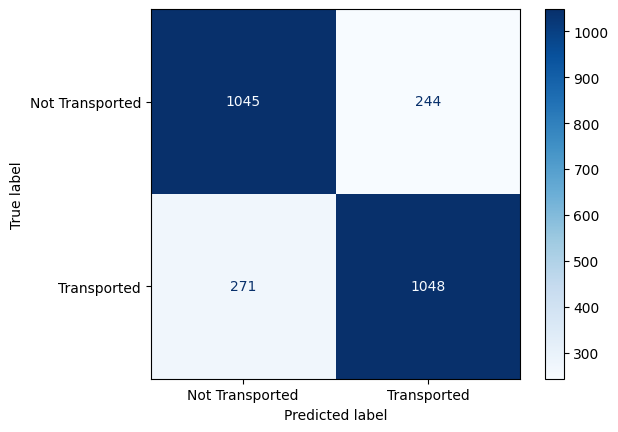

In [182]:
ConfusionMatrixDisplay.from_predictions(
    Y_test,
    Y_pred,
    display_labels=["Not Transported", "Transported"],
    cmap="Blues"
)
plt.show()